# BERT/RoBERTa Sentiment Fine-tuning — Guitar Reviews

**Task:** Fine-tune RoBERTa on guitar reviews using rating-based labels, then analyze sentiment per topic.

**Label scheme:**
- Rating 4–5 → `positive` (1)
- Rating 1–2 → `negative` (0)
- Rating 3   → excluded from training (too ambiguous)

**Key fixed parameters:** `test_size=0.2`, `random_state=42`

---
### How to switch between LOCAL (debug) and FULL (HPC) mode
Set `DEBUG_MODE = True` below to run on 500 samples locally.  
Set `DEBUG_MODE = False` before converting to `.py` for HPC submission.

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Fix random seeds for reproducibility across runs
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"Transformers    : OK")
print(f"Random seeds fixed to {SEED}")

PyTorch version : 2.10.0
Transformers    : OK
Random seeds fixed to 42


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Toggle: True = 500-sample local debug | False = full dataset for HPC
DEBUG_MODE = True
DEBUG_SAMPLE_SIZE = 500

# Fixed project parameters (do not change)
TEST_SIZE    = 0.2
RANDOM_STATE = 42

# Model
MODEL_NAME  = "roberta-base"
MAX_LENGTH  = 256
NUM_LABELS  = 2

# Training hyperparameters
BATCH_SIZE     = 8 if DEBUG_MODE else 16
NUM_EPOCHS     = 2 if DEBUG_MODE else 3
LEARNING_RATE  = 2e-5

# Paths
DATA_PATH   = "../../guitars_with_topics_v2.parquet"
OUTPUT_DIR  = "./roberta_sentiment_model"

# ── Force CPU in debug mode ───────────────────────────────────────────────────
# HuggingFace Trainer has its own device detection that ignores a DEVICE variable.
# The only reliable way to prevent Trainer from using MPS is to patch PyTorch
# so it reports MPS as unavailable. This affects only this session.
if DEBUG_MODE:
    torch.backends.mps.is_available = lambda: False   # Trainer will not pick MPS
    torch.backends.mps.is_built     = lambda: False
    print("[DEBUG] MPS disabled — Trainer will use CPU")

DEVICE = torch.device("cpu") if DEBUG_MODE else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)

print(f"Running in {'DEBUG (500 samples)' if DEBUG_MODE else 'FULL'} mode")
print(f"Device : {DEVICE}")

## Step 1 — Load Data & Create Labels

In [4]:
# ── Load the dataset ──────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} reviews")
print(f"Columns: {df.columns.tolist()}")

Loaded 134,068 reviews
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'subcategory', 'store', 'average_rating', 'price', 'topic_id', 'topic_label', 'topic_prob']


In [5]:
# ── Create sentiment labels from ratings ──────────────────────────────────────
# Rating 4-5 → positive (1) | Rating 1-2 → negative (0) | Rating 3 → dropped

def assign_label(rating):
    if rating >= 4:
        return 1   # positive
    elif rating <= 2:
        return 0   # negative
    else:
        return None  # neutral — exclude from training

df['label'] = df['rating'].apply(assign_label)

# Keep only labelled rows for training/evaluation
df_labelled = df.dropna(subset=['label']).copy()
df_labelled['label'] = df_labelled['label'].astype(int)

# Also keep all rows (including rating=3) for the final per-topic inference
df_all = df.copy()

print(f"Total reviews     : {len(df):,}")
print(f"After dropping 3★ : {len(df_labelled):,}")
print()
print("Label distribution:")
counts = df_labelled['label'].value_counts().sort_index()
for lbl, cnt in counts.items():
    name = 'positive' if lbl == 1 else 'negative'
    print(f"  {name} ({lbl}): {cnt:,}  ({cnt/len(df_labelled)*100:.1f}%)")

Total reviews     : 134,068
After dropping 3★ : 124,243

Label distribution:
  negative (0): 18,523  (14.9%)
  positive (1): 105,720  (85.1%)


## Step 2 — Train / Test Split

In [6]:
# ── Optional: subsample for local debug ───────────────────────────────────────
if DEBUG_MODE:
    df_labelled = df_labelled.sample(
        n=DEBUG_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)
    print(f"[DEBUG] Using {len(df_labelled)} samples")

# ── Train / test split (fixed parameters) ────────────────────────────────────
train_df, test_df = train_test_split(
    df_labelled,
    test_size=TEST_SIZE,       # 0.2 — fixed project parameter
    random_state=RANDOM_STATE, # 42  — fixed project parameter
    stratify=df_labelled['label']  # keep class ratio in both splits
)

# ── Further split train → train + validation ──────────────────────────────────
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,             # 10% of training set as validation
    random_state=RANDOM_STATE,
    stratify=train_df['label']
)

print(f"Train set : {len(train_df):,}")
print(f"Val set   : {len(val_df):,}")
print(f"Test set  : {len(test_df):,}")

[DEBUG] Using 500 samples
Train set : 360
Val set   : 40
Test set  : 100


## Step 3 — Tokenisation

In [7]:
# ── Load tokenizer ────────────────────────────────────────────────────────────
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

# Quick sanity check: see how a sample review is tokenised
sample = "This guitar stays in tune perfectly! Great value for money."
tokens = tokenizer(sample, truncation=True, max_length=MAX_LENGTH)
print(f"Sample token IDs : {tokens['input_ids']}")
print(f"Token count      : {len(tokens['input_ids'])}")

Sample token IDs : [0, 713, 8669, 10117, 11, 8859, 6683, 328, 2860, 923, 13, 418, 4, 2]
Token count      : 14


In [8]:
# ── PyTorch Dataset wrapper ───────────────────────────────────────────────────
class ReviewDataset(Dataset):
    """Converts a DataFrame of reviews + labels into a PyTorch Dataset."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.labels    = list(labels)
        # Tokenise all texts at once (padding + truncation)
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_length
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Return one sample as a dict of tensors
        item = {key: torch.tensor(val[idx])
                for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item


# Build datasets for each split
train_dataset = ReviewDataset(train_df['text'], train_df['label'], tokenizer, MAX_LENGTH)
val_dataset   = ReviewDataset(val_df['text'],   val_df['label'],   tokenizer, MAX_LENGTH)
test_dataset  = ReviewDataset(test_df['text'],  test_df['label'],  tokenizer, MAX_LENGTH)

print(f"Train dataset : {len(train_dataset)} samples")
print(f"Val dataset   : {len(val_dataset)} samples")
print(f"Test dataset  : {len(test_dataset)} samples")

Train dataset : 360 samples
Val dataset   : 40 samples
Test dataset  : 100 samples


## Step 4 — Load Model & Define Metrics

In [9]:
# ── Load pre-trained RoBERTa with a classification head ───────────────────────
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model.to(DEVICE)

print(f"Model loaded: {MODEL_NAME}")
print(f"Parameters  : {sum(p.numel() for p in model.parameters()):,}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7969.50it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: roberta-base
Parameters  : 124,647,170


In [10]:
# ── Evaluation metrics: Accuracy + Macro F1 ───────────────────────────────────
# Macro F1 treats positive and negative equally regardless of class imbalance,
# which is important since our dataset has ~85% positive reviews.

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)  # pick the higher-probability class
    return {
        'accuracy' : accuracy_score(labels, predictions),
        'macro_f1' : f1_score(labels, predictions, average='macro'),
    }

## Step 5 — Training

In [11]:
# ── Training arguments ────────────────────────────────────────────────────────
# Note: eval_strategy (not evaluation_strategy) is required for transformers >= 4.46
# Note: load_best_model_at_end is disabled in DEBUG mode — it triggers a
#       checkpoint reload that has missing-key warnings and can corrupt the model.
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = LEARNING_RATE,
    weight_decay                = 0.01,             # mild L2 regularisation
    eval_strategy               = "epoch",          # evaluate after every epoch
    save_strategy               = "epoch" if not DEBUG_MODE else "no",   # skip saving in debug
    load_best_model_at_end      = False if DEBUG_MODE else True,           # skip in debug
    metric_for_best_model       = "macro_f1",
    greater_is_better           = True,
    logging_steps               = 10,
    report_to                   = "none",           # disable W&B / MLflow
)

# ── Trainer ───────────────────────────────────────────────────────────────────
callbacks = [] if DEBUG_MODE else [EarlyStoppingCallback(early_stopping_patience=2)]

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = callbacks,
)

print("Starting training...")
trainer.train()

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.352247,0.286759,0.875000,0.466667
2,0.087061,0.139938,0.900000,0.722222


TrainOutput(global_step=90, training_loss=0.2975970175531175, metrics={'train_runtime': 315.3063, 'train_samples_per_second': 2.283, 'train_steps_per_second': 0.285, 'total_flos': 94719979929600.0, 'train_loss': 0.2975970175531175, 'epoch': 2.0})

## Step 6 — Evaluate on Test Set

In [12]:
# ── Evaluate on held-out test set ─────────────────────────────────────────────
# We use manual PyTorch inference instead of Trainer.evaluate() to avoid
# callback state conflicts (on_train_begin must be called before on_evaluate).

model.eval()   # switch model to evaluation mode (disables dropout)

all_preds  = []
all_labels = []

dataloader = DataLoader(test_dataset, batch_size=32)
with torch.no_grad():
    for batch in dataloader:
        labels = batch.pop("labels")
        outputs = model(**{k: v.to(DEVICE) for k, v in batch.items()})
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
test_macro_f1 = f1_score(all_labels, all_preds, average="macro")

print("=" * 40)
print("TEST SET RESULTS")
print("=" * 40)
print(f"  Accuracy : {test_accuracy:.4f}")
print(f"  Macro F1 : {test_macro_f1:.4f}")

TEST SET RESULTS
  Accuracy : 0.9700
  Macro F1 : 0.9314


In [13]:
# ── Detailed classification report ───────────────────────────────────────────
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.92      0.85      0.88        13
    Positive       0.98      0.99      0.98        87

    accuracy                           0.97       100
   macro avg       0.95      0.92      0.93       100
weighted avg       0.97      0.97      0.97       100



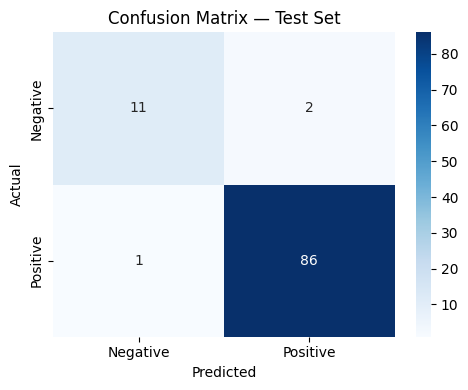

In [14]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## Step 7 — Save Model

In [16]:
# ── Save the fine-tuned model and tokenizer ───────────────────────────────────
# This lets you reload the model later without re-training
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to: {OUTPUT_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:21<00:00, 21.05s/it]

Model saved to: ./roberta_sentiment_model


## Step 8 — Per-Topic Sentiment Analysis (Main Output)

In [17]:
# ── Run inference on ALL reviews (including rating=3) ─────────────────────────
# We use the full dataset here, not just the labelled training split.
# The model predicts sentiment even for 3-star reviews.

inference_df = df_all.copy()
if DEBUG_MODE:
    inference_df = inference_df.sample(n=300, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"[DEBUG] Running inference on {len(inference_df)} reviews")
else:
    print(f"Running inference on {len(inference_df):,} reviews")

# Build dataset (labels=-1 as placeholder, not used)
infer_dataset = ReviewDataset(
    inference_df["text"],
    [-1] * len(inference_df),
    tokenizer,
    MAX_LENGTH
)

# Manual inference with DataLoader
model.eval()
all_infer_preds  = []
all_infer_probs  = []

infer_loader = DataLoader(infer_dataset, batch_size=32)
with torch.no_grad():
    for batch in infer_loader:
        batch.pop("labels")   # remove placeholder labels
        outputs = model(**{k: v.to(DEVICE) for k, v in batch.items()})
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_infer_preds.extend(preds.cpu().numpy())
        all_infer_probs.extend(probs[:, 1].cpu().numpy())   # probability of positive

inference_df["pred_label"]    = all_infer_preds
inference_df["pred_pos_prob"] = all_infer_probs
inference_df["pred_sentiment"] = inference_df["pred_label"].map({1: "positive", 0: "negative"})

print("Inference complete.")
print(inference_df[["text", "rating", "topic_label", "pred_sentiment", "pred_pos_prob"]].head(3).to_string())

[DEBUG] Running inference on 300 reviews
Inference complete.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [18]:
# ── Compute per-topic sentiment distribution ──────────────────────────────────
topic_sentiment = (
    inference_df
    .groupby('topic_label')['pred_sentiment']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'positive': 'pos_rate', 'negative': 'neg_rate'})
    .sort_values('pos_rate', ascending=False)
)

# Also add average predicted positive probability per topic
topic_avg_prob = inference_df.groupby('topic_label')['pred_pos_prob'].mean()
topic_sentiment['avg_pos_prob'] = topic_avg_prob

# Add review count per topic
topic_sentiment['count'] = inference_df.groupby('topic_label').size()

print("\n=== Per-Topic Sentiment Distribution ===")
print(topic_sentiment.round(3).to_string())


=== Per-Topic Sentiment Distribution ===
pred_sentiment              neg_rate  pos_rate  avg_pos_prob  count
topic_label                                                        
Pickups                        0.000     1.000         0.982     14
Setup / action                 0.000     1.000         0.996      8
Visual appearance              0.000     1.000         0.997     10
Beginner learning              0.029     0.971         0.972     35
Acoustic tone                  0.111     0.889         0.924      9
Playability / chords           0.154     0.846         0.909     13
Guitar size                    0.176     0.824         0.887     17
String quality                 0.214     0.786         0.791     14
Accessories                    0.217     0.783         0.840     23
Fret / neck setup              0.314     0.686         0.778     35
Electronics / controls         0.333     0.667         0.787      3
Tuning stability               0.444     0.556         0.695     18
Custom

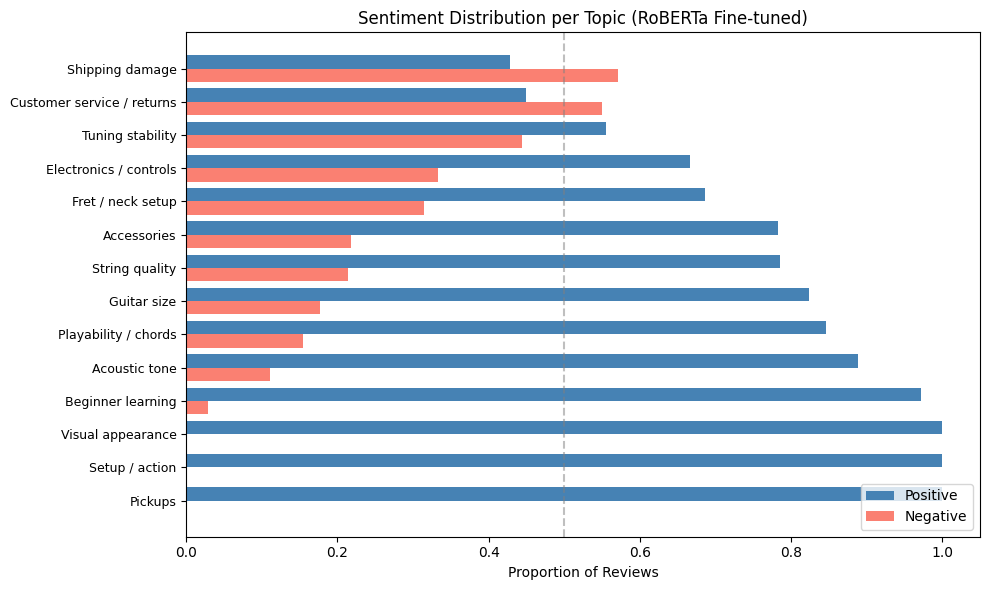

Chart saved to topic_sentiment.png


In [19]:
# ── Visualise per-topic sentiment ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

topics  = topic_sentiment.index
pos_rates = topic_sentiment.get('pos_rate', pd.Series(dtype=float))
neg_rates = topic_sentiment.get('neg_rate', pd.Series(dtype=float))

x = np.arange(len(topics))
width = 0.4

ax.barh(x + width/2, pos_rates, width, label='Positive', color='steelblue')
ax.barh(x - width/2, neg_rates, width, label='Negative', color='salmon')

ax.set_yticks(x)
ax.set_yticklabels(topics, fontsize=9)
ax.set_xlabel('Proportion of Reviews')
ax.set_title('Sentiment Distribution per Topic (RoBERTa Fine-tuned)')
ax.legend(loc='lower right')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('topic_sentiment.png', dpi=150)
plt.show()
print("Chart saved to topic_sentiment.png")

In [20]:
# ── Save final results to CSV ─────────────────────────────────────────────────
# Full prediction table (each review with its predicted sentiment)
inference_df.to_csv('bert_predictions.csv', index=False)

# Per-topic summary table
topic_sentiment.to_csv('bert_topic_sentiment.csv')

print("Saved: bert_predictions.csv")
print("Saved: bert_topic_sentiment.csv")
print("\nDone!")

Saved: bert_predictions.csv
Saved: bert_topic_sentiment.csv

Done!
